In [ ]:
"""

REAL WORLD APPROACH
1. Data Understanding
2. EDA
3. Feature Selection
4. Scaling
5. Baseline KMeans
6. Cluster Assignment
7. Internal Validation Metrics
8. Hyperparameter Tuning
9. Elbow Method
10. Silhouette Analysis
11. PCA Visualization
12. Cluster Profiling
13. Stability Analysis
14. Deployment Readiness
15. Interview Questions
"""
# ================================================================
# STEP 0 : IMPORTS
# ================================================================

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score,davies_bouldin_score,calinski_harabasz_score)
from sklearn.decomposition import PCA
import joblib

In [2]:
# ================================================================
# STEP 1 : DATA UNDERSTANDING
# ================================================================

wine = load_wine()
df = pd.DataFrame(wine.data,columns=wine.feature_names)

print(df.head())
print(df.info())
print(df.describe())
print(df.shape)

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64
0


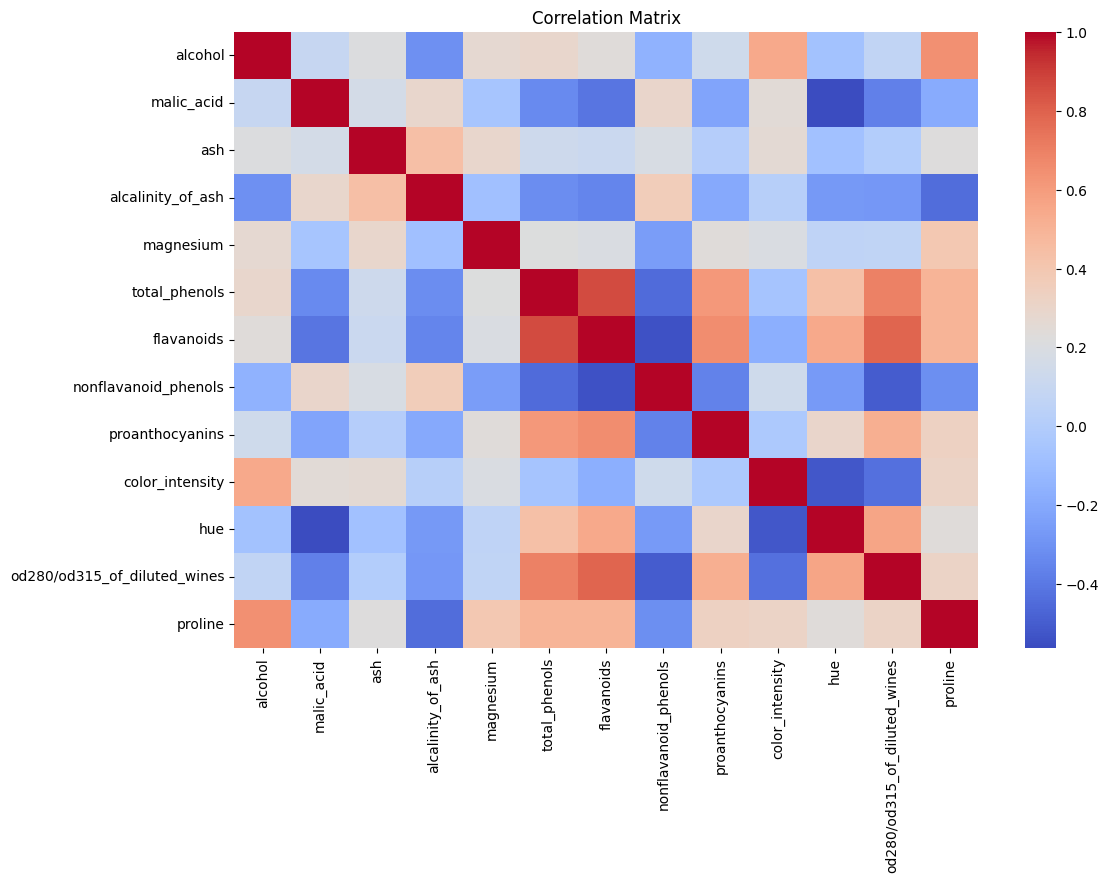

In [4]:
# ================================================================
# STEP 2 : EDA
# ================================================================

print(df.isnull().sum())
print(df.duplicated().sum())

# Correlation Matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [5]:
# ================================================================
# STEP 3 : FEATURE SELECTION
# ================================================================
# No target variable in clustering
X = df.copy()

In [6]:
# ================================================================
# STEP 4 : SCALING
# ================================================================

"""
KMeans uses Euclidean Distance.
Features with larger values dominate
distance calculations.
Therefore scaling is mandatory.
"""
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nScaled Shape:", X_scaled.shape)


Scaled Shape: (178, 13)


In [7]:
# ================================================================
# STEP 5 : BASELINE MODEL
# ================================================================

kmeans = KMeans(n_clusters=3,init='k-means++',n_init=20,max_iter=300,random_state=42)
print(kmeans)

KMeans(n_clusters=3, n_init=20, random_state=42)


In [8]:
# ================================================================
# STEP 6 : CLUSTER ASSIGNMENT
# ================================================================

labels = kmeans.fit_predict(X_scaled)
df["cluster"] = labels
print("\nCluster Counts")
print(df["cluster"].value_counts())


Cluster Counts
cluster
0    65
2    62
1    51
Name: count, dtype: int64


In [9]:
# ================================================================
# STEP 7 : INTERNAL VALIDATION
# ================================================================

sil_score = silhouette_score(X_scaled,labels)
db_score = davies_bouldin_score(X_scaled,labels)
ch_score = calinski_harabasz_score(X_scaled,labels)

print("\nInternal Validation Metrics")
print("Silhouette Score:", sil_score)
print("Davies Bouldin Score:", db_score)
print("Calinski Harabasz Score:", ch_score)


Internal Validation Metrics
Silhouette Score: 0.2848589191898987
Davies Bouldin Score: 1.3891879777181648
Calinski Harabasz Score: 70.94000800315118


In [10]:
# ================================================================
# STEP 8 : HYPERPARAMETER TUNING
# ================================================================

"""
For KMeans
Main hyperparameter:
n_clusters
"""
results = []
for k in range(2,11):
    model = KMeans(n_clusters=k,init='k-means++',n_init=20,random_state=42)
    cluster_labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled,cluster_labels)
    results.append([k,score])

tuning_df = pd.DataFrame(results,columns=["K","Silhouette"])
print("\nHyperparameter Search")
print(tuning_df)
best_k = tuning_df.loc[tuning_df["Silhouette"].idxmax(),"K"]
print("\nBest K:", best_k)


Hyperparameter Search
    K  Silhouette
0   2    0.259317
1   3    0.284859
2   4    0.258608
3   5    0.231528
4   6    0.237167
5   7    0.203628
6   8    0.157014
7   9    0.149882
8  10    0.143638

Best K: 3


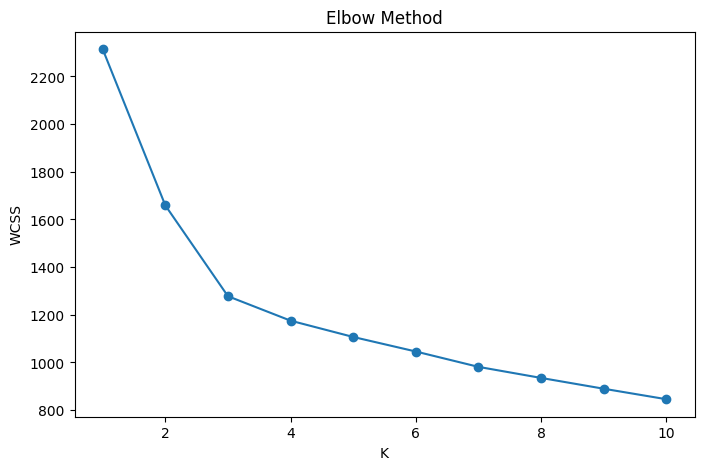

In [11]:
# ================================================================
# STEP 9 : ELBOW METHOD
# ================================================================

wcss = []

for k in range(1,11):
    model = KMeans(n_clusters=k,init='k-means++',n_init=20,random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

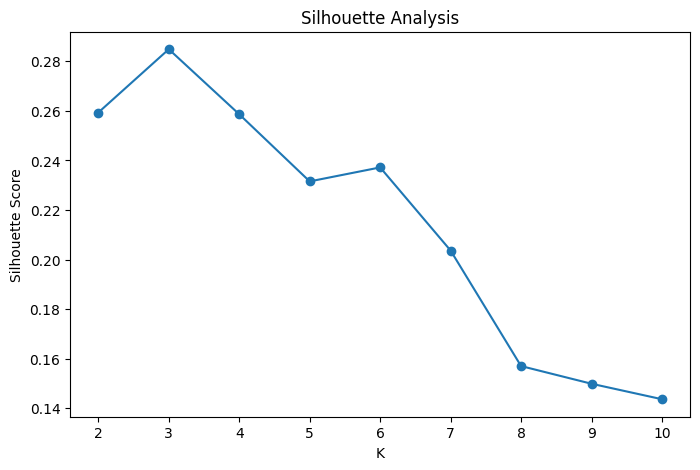

In [12]:
# ================================================================
# STEP 10 : SILHOUETTE ANALYSIS
# ================================================================

silhouette_scores = []

for k in range(2,11):
    model = KMeans(n_clusters=k,n_init=20,random_state=42)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled,labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2,11),silhouette_scores,marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

# ================================================================
# BEST MODEL
# ================================================================

best_model = KMeans(n_clusters=int(best_k),init='k-means++',n_init=20,max_iter=300,random_state=42)
labels = best_model.fit_predict(X_scaled)
df["cluster"] = labels

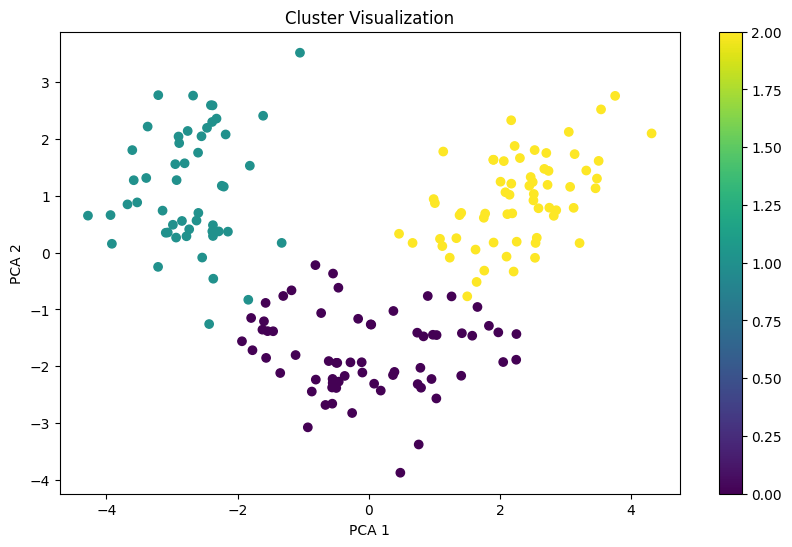

In [13]:
# ================================================================
# STEP 11 : PCA VISUALIZATION
# ================================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10,6))
scatter = plt.scatter(X_pca[:,0],X_pca[:,1],c=labels,cmap="viridis")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Cluster Visualization")
plt.colorbar(scatter)
plt.show()

In [ ]:
# ================================================================
# STEP 12 : CLUSTER PROFILING
# ================================================================

"""
Most Important Real World Step
Business Interpretation
"""
cluster_profile = df.groupby("cluster").mean()
print("\nCluster Profile")
print(cluster_profile)

# Cluster Sizes
print("\nCluster Sizes")
print(df["cluster"].value_counts())


Cluster Profile
           alcohol  malic_acid       ash  alcalinity_of_ash   magnesium  \
cluster                                                                   
0        12.250923    1.897385  2.231231          20.063077   92.738462   
1        13.134118    3.307255  2.417647          21.241176   98.666667   
2        13.676774    1.997903  2.466290          17.462903  107.967742   

         total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
cluster                                                                     
0             2.247692    2.050000              0.357692         1.624154   
1             1.683922    0.818824              0.451961         1.145882   
2             2.847581    3.003226              0.292097         1.922097   

         color_intensity       hue  od280/od315_of_diluted_wines      proline  
cluster                                                                        
0               2.973077  1.062708                      2.803

In [15]:
# ================================================================
# STEP 13 : STABILITY ANALYSIS
# ================================================================

"""
Equivalent of checking
generalization in clustering.
Run with multiple seeds.
"""

seeds = [1,42,100,500]

for seed in seeds:
    model = KMeans(n_clusters=int(best_k),n_init=20,random_state=seed)
    labels_seed = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled,labels_seed)
    print(f"Seed={seed} "f"Silhouette={score:.4f}")

Seed=1 Silhouette=0.2849
Seed=42 Silhouette=0.2849
Seed=100 Silhouette=0.2849
Seed=500 Silhouette=0.2849


In [16]:
# ================================================================
# STEP 14 : DEPLOYMENT READINESS
# ================================================================

joblib.dump(best_model,"kmeans_model.pkl")
joblib.dump(scaler,"kmeans_scaler.pkl")
print("\nArtifacts Saved")
print("kmeans_model.pkl")
print("kmeans_scaler.pkl")

# Example Prediction

sample = X.iloc[[0]]
sample_scaled = scaler.transform(sample)
cluster_prediction = best_model.predict(sample_scaled)
print("\nSample Assigned Cluster:",cluster_prediction[0])


Artifacts Saved
kmeans_model.pkl
kmeans_scaler.pkl

Sample Assigned Cluster: 2


# ================================================================
# STEP 15 : INTERVIEW QUESTIONS
# ================================================================

"""
1. What is KMeans?
2. What is a centroid?
3. Why scaling is mandatory?
4. Explain Euclidean Distance.
5. What is inertia?
6. What is WCSS?
7. Explain Elbow Method.
8. Explain Silhouette Score.
9. What is Davies-Bouldin Score?
10. What is Calinski-Harabasz Score?
11. Why use k-means++?
12. What is n_init?
13. What happens if K is too small?
14. What happens if K is too large?
15. Why KMeans struggles with outliers?
16. Why KMeans assumes spherical clusters?
17. Explain PCA visualization.
18. What is cluster profiling?
19. How do you validate clustering?
20. Explain KMeans end-to-end.
21. Difference between KMeans and DBSCAN?
22. Difference between KMeans and Hierarchical?
23. What are limitations of KMeans?
24. How would you deploy a KMeans model?
25. Real-world applications of KMeans?
"""

# ================================================================
# END OF FILE
# ================================================================